--- MODEL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



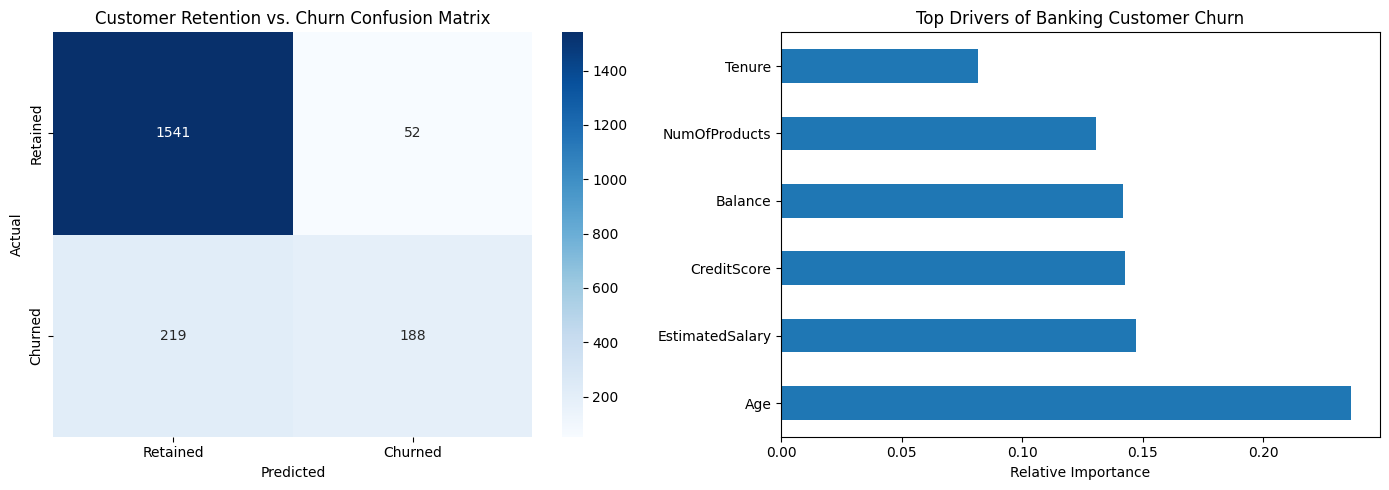

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load data directly
url = "https://raw.githubusercontent.com/selva86/datasets/master/Churn_Modelling.csv"
df = pd.read_csv(url)

# 2. Preprocess features
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df_clean = pd.get_dummies(df_clean, drop_first=True)

X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# 3. Train/Test split & Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluation Metrics
y_pred = model.predict(X_test)
print("--- MODEL PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred))

# 5. Visualizations
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
ax[0].set_title('Customer Retention vs. Churn Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Top Churn Indicators (Feature Importance)
feat_importances = pd.Series(model.feature_importances_, index=X.columns).nlargest(6)
feat_importances.plot(kind='barh', ax=ax[1], color='#1f77b4')
ax[1].set_title('Top Drivers of Banking Customer Churn')
ax[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.savefig('churn_analysis_charts.png')
plt.show()